## Carga del dataset y preparación de conjuntos

Cargamos el dataset procesado generado en `preprocess.ipynb` y realizamos la división en tres conjuntos disjuntos con las mismas proporciones y semilla usadas en el preprocesado:

| Conjunto | Proporción | Uso |
|---|---|---|
| `X_train` | 70% | Entrenamiento de todos los modelos |
| `X_val` | 15% | Validación durante el entrenamiento (early stopping en redes neuronales) |
| `X_test` | 15% | Evaluación final — nunca visto durante entrenamiento ni selección de hiperparámetros |

La semilla `random_state=42` garantiza que todos los modelos se evalúan sobre exactamente el mismo conjunto de test, haciendo la comparativa final válida y reproducible.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import TomekLinks

processed_dataset = pd.read_csv(r'processed_dataset.csv')
Y = processed_dataset.salario
X = processed_dataset.drop('salario', axis=1)

# División 70/15/15
X_trainval, X_test, Y_trainval, Y_test = train_test_split(
    X, Y, test_size=0.15, shuffle=True, random_state=42
)
X_train, X_val, Y_train, Y_val = train_test_split(
    X_trainval, Y_trainval, test_size=0.176, shuffle=True, random_state=42
)

print(f'Train:      {X_train.shape[0]} instancias')
print(f'Validación: {X_val.shape[0]} instancias')
print(f'Test:       {X_test.shape[0]} instancias')

Train:      17664 instancias
Validación: 3773 instancias
Test:       3784 instancias


### Tratamiento del desbalanceo — TomekLinks

TomekLinks identifica y elimina pares de instancias de clases distintas que son vecinos más cercanos entre sí (instancias fronterizas o ruidosas de la clase mayoritaria). Es un método de **undersampling de limpieza**: no genera datos sintéticos sino que elimina instancias ambiguas que dificultan la separación entre clases.

Se aplica **exclusivamente sobre `X_train`** para no contaminar la evaluación. `X_val` y `X_test` se mantienen con la distribución original.

In [2]:
tl = TomekLinks(n_jobs=-1)
X_train_tl, Y_train_tl = tl.fit_resample(X_train.values, Y_train)

print(f'Train original:   {dict(zip(*np.unique(Y_train, return_counts=True)))}')
print(f'Train TomekLinks: {dict(zip(*np.unique(Y_train_tl, return_counts=True)))}')

Train original:   {np.int64(0): np.int64(13274), np.int64(1): np.int64(4390)}
Train TomekLinks: {np.int64(0): np.int64(12532), np.int64(1): np.int64(4390)}


# Aplicación de modelos de aprendizaje supervisado

Sobre el dataset procesado evaluamos todos los modelos requeridos por el enunciado, realizando en cada caso una búsqueda de hiperparámetros mediante `GridSearchCV` con 5 folds. La métrica principal es el **F1-score weighted average**, que pondera el F1 de cada clase por su soporte, siendo más informativa que el F1 binario en presencia de desbalanceo.

Todos los modelos se evalúan sobre el mismo `X_test` con umbral fijo θ=0.5.

## 1. Métodos clasicos:


### 1.1 Regresión Lineal

La regresión lineal modela la relación entre las features y la etiqueta como `f(x) = wx + b`, minimizando el Error Cuadrático Medio (MSE). Su solución analítica por mínimos cuadrados no tiene hiperparámetros, por lo que se usa como **baseline** comparativo.

Al producir salidas continuas se aplica un umbral fijo θ=0.5 para clasificar: `ŷ=1` si `f(x) > 0.5`.

Para controlar el overfitting se evalúan dos variantes regularizadas:
- **Ridge (L2):** añade `α·Σwj²` al coste. Encoge los coeficientes pero no los lleva a cero.
- **Lasso (L1):** añade `α·Σ|wj|`. Lleva coeficientes a exactamente cero, realizando selección implícita de features.

El hiperparámetro α se optimiza con `GridSearchCV` (5 folds).

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import f1_score, classification_report, make_scorer
from sklearn.model_selection import GridSearchCV

# Scorer con umbral aplicado: necesario porque predict() devuelve valores continuos
scorer = make_scorer(
    lambda y_true, y_pred: f1_score(
        y_true, (y_pred > 0.5).astype(int), average='weighted'
    )
)

#baseline
pred_ols = (LinearRegression().fit(X_train_tl, Y_train_tl).predict(X_test.values) > 0.5).astype(int)
print('── OLS ──')
print(f'F1 weighted (θ=0.5): {f1_score(Y_test, pred_ols, average="weighted"):.4f}')
print(classification_report(Y_test, pred_ols, target_names=['<=50K', '>50K']))

#ridge
grid_ridge = GridSearchCV(
    Ridge(), {'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]},
    cv=5, scoring=scorer, n_jobs=-1
).fit(X_train_tl, Y_train_tl)

pred_ridge = (grid_ridge.predict(X_test.values) > 0.5).astype(int)
print(f'── Ridge (α={grid_ridge.best_params_["alpha"]}) ──')
print(f'F1 weighted (θ=0.5): {f1_score(Y_test, pred_ridge, average="weighted"):.4f}')
print(classification_report(Y_test, pred_ridge, target_names=['<=50K', '>50K']))

#Lasso
grid_lasso = GridSearchCV(
    Lasso(max_iter=10000), {'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]},
    cv=5, scoring=scorer, n_jobs=-1
).fit(X_train_tl, Y_train_tl)

pred_lasso = (grid_lasso.predict(X_test.values) > 0.5).astype(int)
n_ceros    = (grid_lasso.best_estimator_.coef_ == 0).sum()
print(f'── Lasso (α={grid_lasso.best_params_["alpha"]}, {n_ceros} features eliminadas) ──')
print(f'F1 weighted (θ=0.5): {f1_score(Y_test, pred_lasso, average="weighted"):.4f}')
print(classification_report(Y_test, pred_lasso, target_names=['<=50K', '>50K']))

── OLS ──
F1 weighted (θ=0.5): 0.8404
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90      2918
        >50K       0.70      0.57      0.63       866

    accuracy                           0.85      3784
   macro avg       0.79      0.75      0.77      3784
weighted avg       0.84      0.85      0.84      3784

── Ridge (α=0.001) ──
F1 weighted (θ=0.5): 0.8404
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90      2918
        >50K       0.70      0.57      0.63       866

    accuracy                           0.85      3784
   macro avg       0.79      0.75      0.77      3784
weighted avg       0.84      0.85      0.84      3784

── Lasso (α=0.0001, 17 features eliminadas) ──
F1 weighted (θ=0.5): 0.8376
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90      2918
        >50K       0.69      0.56      0.62       866

    accuracy       

### 1.2 Regresión Polinomial

La regresión polinomial expande el espacio de features añadiendo términos de grado superior y productos cruzados. Con el número de features del dataset y grado 2 se generan aproximadamente 2.850 features, haciendo inviable un `GridSearchCV` completo por coste computacional.

Se usa **Ridge con α=1** directamente como regularizador para controlar el overfitting que introduce la alta dimensionalidad.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import f1_score, classification_report 

poly         = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_tl)
X_test_poly  = poly.transform(X_test.values)

pred_poly = (Ridge(alpha=1).fit(X_train_poly, Y_train_tl).predict(X_test_poly) > 0.5).astype(int)

print('── Regresión Polinomial (grado 2, Ridge α=1) ──')
print(f'F1 weighted (θ=0.5): {f1_score(Y_test, pred_poly, average="weighted"):.4f}')
print(classification_report(Y_test, pred_poly, target_names=['<=50K', '>50K']))

── Regresión Polinomial (grado 2, Ridge α=1) ──
F1 weighted (θ=0.5): 0.8400
              precision    recall  f1-score   support

       <=50K       0.89      0.90      0.90      2918
        >50K       0.66      0.63      0.64       866

    accuracy                           0.84      3784
   macro avg       0.78      0.77      0.77      3784
weighted avg       0.84      0.84      0.84      3784



La alta dimensionalidad generada por las expansiones polinomiales limita la posibilidad de optimizar hiperparámetros y subir de grado, lo que restringe el potencial de este método en este contexto.

### 1.3 Regresión Logística

La regresión logística modela directamente la probabilidad de clase: `P(y=1|x) = 1/(1+e^-(wx+b)) ∈ (0,1)`, optimizando la Binary Cross-Entropy. Su salida es directamente interpretable como probabilidad.

Se explora la penalización **ElasticNet** mediante `l1_ratio`:
- `l1_ratio=0` → L2 puro: encoge coeficientes sin eliminarlos
- `l1_ratio=1` → L1 puro: lleva coeficientes a cero (selección implícita)
- `0 < l1_ratio < 1` → combinación de ambas

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report, make_scorer
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

scorer = make_scorer(f1_score, average='weighted')

grid = GridSearchCV(
    LogisticRegression( solver='saga', max_iter=5000),
    {'C': [0.1, 1, 10, 100], 'l1_ratio': [0, 0.25, 0.5, 0.75, 1]},
    cv=5, scoring=scorer, n_jobs=-1
).fit(X_train_tl, Y_train_tl)

pred_log = grid.best_estimator_.predict(X_test.values)

print(f'Mejores hiperparámetros: C={grid.best_params_["C"]}, l1_ratio={grid.best_params_["l1_ratio"]}')
print(f'F1 weighted (θ=0.5): {f1_score(Y_test, pred_log, average="weighted"):.4f}')
print(classification_report(Y_test, pred_log, target_names=['<=50K', '>50K']))

Mejores hiperparámetros: C=10, l1_ratio=0.25
F1 weighted (θ=0.5): 0.8372
              precision    recall  f1-score   support

       <=50K       0.89      0.90      0.90      2918
        >50K       0.66      0.62      0.64       866

    accuracy                           0.84      3784
   macro avg       0.77      0.76      0.77      3784
weighted avg       0.84      0.84      0.84      3784



## 2. Árboles de Decisión

### 2.1 Árbol de Decisión

Un árbol de decisión divide recursivamente el espacio de features eligiendo en cada nodo el atributo y umbral que maximiza la **ganancia de información**: reducción de impureza antes y después de la partición.

**Criterios de impureza** evaluados:
- **Gini** (CART, defecto sklearn): `Gini = 1 - Σpᵢ²`. Nodo puro → 0, nodo 50/50 → 0.5.
- **Entropía** (ID3/C4.5): `H = -Σpᵢ·log₂(pᵢ)`. Nodo puro → 0, nodo 50/50 → 1.

**Problema principal:** sin restricciones el árbol memoriza el train (overfitting). Los hiperparámetros `max_depth`, `min_samples_split` y `min_samples_leaf` se optimizan con `GridSearchCV` para encontrar el árbol más simple que explique los datos.

Mejores hiperparámetros:
  criterion:         entropy
  max_depth:         None
  min_samples_split: 100
  min_samples_leaf:  20
F1 weighted (θ=0.5): 0.8307
              precision    recall  f1-score   support

       <=50K       0.89      0.90      0.89      2918
        >50K       0.64      0.62      0.63       866

    accuracy                           0.83      3784
   macro avg       0.76      0.76      0.76      3784
weighted avg       0.83      0.83      0.83      3784

F1 weighted train:   0.8624
Profundidad: 31 | Hojas: 246


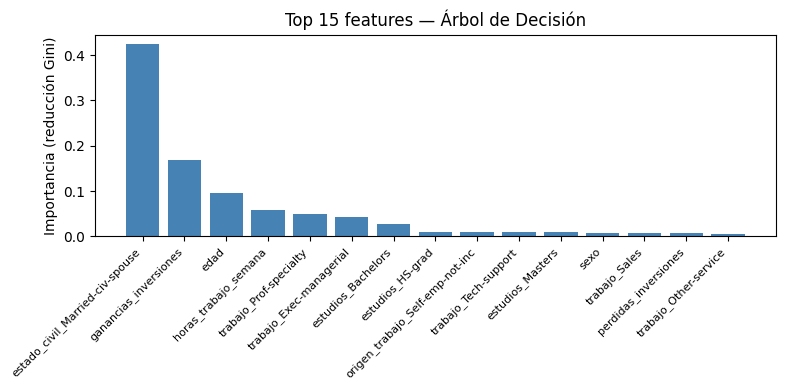

In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, classification_report, make_scorer
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

scorer = make_scorer(f1_score, average='weighted')

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    {
        'criterion':         ['gini', 'entropy', 'log_loss'],
        'max_depth':         [3, 5, 10, 20, None],
        'min_samples_split': [2, 10, 50, 100, 500, 750],
        'min_samples_leaf':  [1, 5, 20, 40, 300],
    },
    cv=5, scoring=scorer, n_jobs=-1
).fit(X_train_tl, Y_train_tl)

best_tree = grid.best_estimator_
pred_tree = best_tree.predict(X_test.values)

print(f'Mejores hiperparámetros:')
print(f'  criterion:         {grid.best_params_["criterion"]}')
print(f'  max_depth:         {grid.best_params_["max_depth"]}')
print(f'  min_samples_split: {grid.best_params_["min_samples_split"]}')
print(f'  min_samples_leaf:  {grid.best_params_["min_samples_leaf"]}')
print(f'F1 weighted (θ=0.5): {f1_score(Y_test, pred_tree, average="weighted"):.4f}')
print(classification_report(Y_test, pred_tree, target_names=['<=50K', '>50K']))
print(f'F1 weighted train:   {f1_score(Y_train_tl, best_tree.predict(X_train_tl), average="weighted"):.4f}')
print(f'Profundidad: {best_tree.get_depth()} | Hojas: {best_tree.get_n_leaves()}')

importancias = best_tree.feature_importances_
indices      = importancias.argsort()[::-1][:15]
plt.figure(figsize=(8, 4))
plt.bar(range(15), importancias[indices], color='steelblue')
plt.xticks(range(15), X_train.columns[indices], rotation=45, ha='right', fontsize=8)
plt.ylabel('Importancia (reducción Gini)')
plt.title('Top 15 features — Árbol de Decisión')
plt.tight_layout()
plt.show()

### 2.2 Random Forest

Random Forest es un método **ensemble** que combina N árboles de decisión entrenados con dos mecanismos de aleatoriedad que reducen la varianza respecto a un árbol individual:

1. **Bagging:** cada árbol entrena sobre un bootstrap sample (muestreo con reemplazo del ~63% de las instancias).
2. **Aleatoriedad en features:** en cada nodo se evalúa solo un subconjunto aleatorio de `max_features` features, decorrelacionando los árboles entre sí.

La predicción final es el **majority voting** de todos los árboles. Al promediar N árboles decorrelacionados la varianza se reduce sin aumentar el sesgo, mejorando la generalización respecto al árbol individual.

Mejores hiperparámetros:
  n_estimators:     200
  max_features:     sqrt
  max_depth:        20
  min_samples_leaf: 1
F1 weighted (θ=0.5): 0.8353
              precision    recall  f1-score   support

       <=50K       0.88      0.91      0.90      2918
        >50K       0.67      0.59      0.63       866

    accuracy                           0.84      3784
   macro avg       0.77      0.75      0.76      3784
weighted avg       0.83      0.84      0.84      3784

F1 weighted train:   0.9294


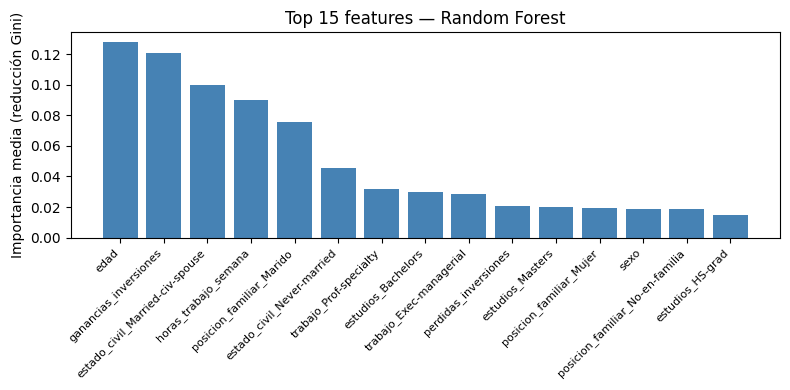

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report, make_scorer
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

scorer = make_scorer(f1_score, average='weighted')

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    {
        'criterion':        ['gini', 'entropy'],
        'n_estimators':     [50, 100, 200],
        'max_features':     ['sqrt', 'log2', None],
        'max_depth':        [5, 10, 20, None],
        'min_samples_leaf': [1, 5, 20],
    },
    cv=5, scoring=scorer, n_jobs=-1
).fit(X_train_tl, Y_train_tl)

best_rf  = grid.best_estimator_
pred_rf  = best_rf.predict(X_test.values)

print(f'Mejores hiperparámetros:')
print(f'  n_estimators:     {grid.best_params_["n_estimators"]}')
print(f'  max_features:     {grid.best_params_["max_features"]}')
print(f'  max_depth:        {grid.best_params_["max_depth"]}')
print(f'  min_samples_leaf: {grid.best_params_["min_samples_leaf"]}')
print(f'F1 weighted (θ=0.5): {f1_score(Y_test, pred_rf, average="weighted"):.4f}')
print(classification_report(Y_test, pred_rf, target_names=['<=50K', '>50K']))
print(f'F1 weighted train:   {f1_score(Y_train_tl, best_rf.predict(X_train_tl), average="weighted"):.4f}')

importancias = best_rf.feature_importances_
indices      = importancias.argsort()[::-1][:15]
plt.figure(figsize=(8, 4))
plt.bar(range(15), importancias[indices], color='steelblue')
plt.xticks(range(15), X_train.columns[indices], rotation=45, ha='right', fontsize=8)
plt.ylabel('Importancia media (reducción Gini)')
plt.title('Top 15 features — Random Forest')
plt.tight_layout()
plt.show()

### 2.3 Extra Trees

Extra Trees (Extremely Randomized Trees) añade un nivel adicional de aleatoriedad respecto a Random Forest: en lugar de buscar el umbral óptimo en cada nodo, genera umbrales **aleatorios** y elige el mejor entre ellos. Además no aplica bagging — cada árbol usa todos los datos de entrenamiento.

Esta aleatoriedad extrema decorrelaciona más los árboles entre sí, reduciendo la varianza a costa de un mayor sesgo individual. El resultado es un método típicamente más rápido y de precisión comparable a Random Forest.

Mejores hiperparámetros:
  n_estimators:     200
  max_features:     sqrt
  max_depth:        20
  min_samples_leaf: 1
F1 weighted (θ=0.5): 0.8364
              precision    recall  f1-score   support

       <=50K       0.88      0.91      0.90      2918
        >50K       0.67      0.60      0.63       866

    accuracy                           0.84      3784
   macro avg       0.78      0.75      0.76      3784
weighted avg       0.83      0.84      0.84      3784

F1 weighted train:   0.9205


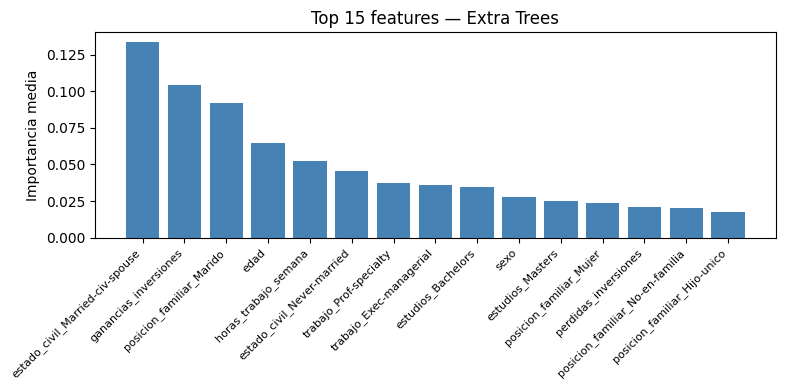

In [5]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import f1_score, classification_report, make_scorer
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

scorer = make_scorer(f1_score, average='weighted')

grid = GridSearchCV(
    ExtraTreesClassifier(random_state=42),
    {
        'n_estimators':     [50, 100, 200],
        'max_features':     ['sqrt', 'log2'],
        'max_depth':        [5, 10, 20, None],
        'min_samples_leaf': [1, 5, 20],
    },
    cv=5, scoring=scorer, n_jobs=-1
).fit(X_train_tl, Y_train_tl)

best_et = grid.best_estimator_
pred_et = best_et.predict(X_test.values)

print(f'Mejores hiperparámetros:')
print(f'  n_estimators:     {grid.best_params_["n_estimators"]}')
print(f'  max_features:     {grid.best_params_["max_features"]}')
print(f'  max_depth:        {grid.best_params_["max_depth"]}')
print(f'  min_samples_leaf: {grid.best_params_["min_samples_leaf"]}')
print(f'F1 weighted (θ=0.5): {f1_score(Y_test, pred_et, average="weighted"):.4f}')
print(classification_report(Y_test, pred_et, target_names=['<=50K', '>50K']))
print(f'F1 weighted train:   {f1_score(Y_train_tl, best_et.predict(X_train_tl), average="weighted"):.4f}')

importancias = best_et.feature_importances_
indices      = importancias.argsort()[::-1][:15]
plt.figure(figsize=(8, 4))
plt.bar(range(15), importancias[indices], color='steelblue')
plt.xticks(range(15), X_train.columns[indices], rotation=45, ha='right', fontsize=8)
plt.ylabel('Importancia media')
plt.title('Top 15 features — Extra Trees')
plt.tight_layout()
plt.show()

## 3. Aprendizaje basado en instancias

### 3.1 KNN — K-Nearest Neighbours

KNN es un algoritmo **basado en instancias**: no aprende ningún modelo en entrenamiento. En predicción calcula la distancia entre la nueva instancia y todas las de train, toma las k más cercanas y asigna la clase mayoritaria.

**Métricas de distancia** exploradas (familia Minkowski):
- `p=1` → Manhattan: más robusta a outliers, no eleva diferencias al cuadrado
- `p=2` → Euclídea: la más común, más sensible a la escala

**Hiperparámetro k:** valores pequeños → overfitting; valores grandes → underfitting. Se exploran valores impares para evitar empates.

**Limitación en alta dimensión:** con el número de features del dataset, la maldición de la dimensionalidad reduce la discriminatividad de las distancias — todos los puntos tienden a distancias similares entre sí.

Mejores hiperparámetros:
  n_neighbors: 11
  weights:     distance
  p (métrica): 2 (Euclídea)
F1 weighted (θ=0.5): 0.8182
              precision    recall  f1-score   support

       <=50K       0.89      0.87      0.88      2918
        >50K       0.59      0.62      0.61       866

    accuracy                           0.82      3784
   macro avg       0.74      0.75      0.74      3784
weighted avg       0.82      0.82      0.82      3784

F1 weighted train:   0.9843


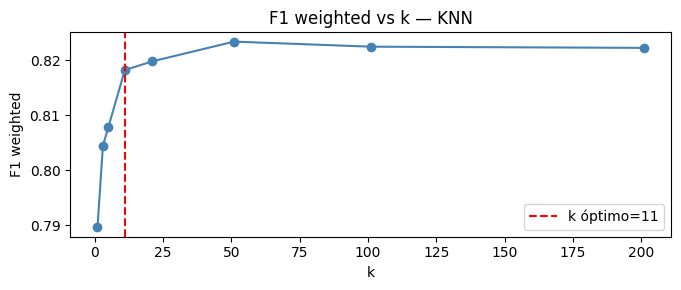

(<matplotlib.legend.Legend at 0x7734a90c9df0>, None, None)

In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, classification_report, make_scorer
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

scorer = make_scorer(f1_score, average='weighted')

grid = GridSearchCV(
    KNeighborsClassifier(algorithm='ball_tree'),
    {
        'n_neighbors': [3, 5, 11, 21, 51, 101],
        'weights':     ['uniform', 'distance'],
        'metric':      ['minkowski'],
        'p':           [1, 2],
    },
    cv=5, scoring=scorer, n_jobs=-1
).fit(X_train_tl, Y_train_tl)

best_knn = grid.best_estimator_
pred_knn = best_knn.predict(X_test.values)

print(f'Mejores hiperparámetros:')
print(f'  n_neighbors: {grid.best_params_["n_neighbors"]}')
print(f'  weights:     {grid.best_params_["weights"]}')
print(f'  p (métrica): {grid.best_params_["p"]} ({"Manhattan" if grid.best_params_["p"]==1 else "Euclídea"})')
print(f'F1 weighted (θ=0.5): {f1_score(Y_test, pred_knn, average="weighted"):.4f}')
print(classification_report(Y_test, pred_knn, target_names=['<=50K', '>50K']))
print(f'F1 weighted train:   {f1_score(Y_train_tl, best_knn.predict(X_train_tl), average="weighted"):.4f}')

# Efecto de k sobre F1 weighted
ks    = [1, 3, 5, 11, 21, 51, 101, 201]
f1s_k = [
    f1_score(Y_test,
             KNeighborsClassifier(n_neighbors=k,
                                  weights=grid.best_params_['weights'],
                                  metric='minkowski',
                                  p=grid.best_params_['p'],
                                  algorithm='ball_tree').fit(X_train_tl, Y_train_tl).predict(X_test.values),
             average='weighted')
    for k in ks
]
plt.figure(figsize=(7, 3))
plt.plot(ks, f1s_k, marker='o', color='steelblue')
plt.axvline(grid.best_params_['n_neighbors'], color='red', linestyle='--',
            label=f'k óptimo={grid.best_params_["n_neighbors"]}')
plt.xlabel('k'), plt.ylabel('F1 weighted')
plt.title('F1 weighted vs k — KNN')
plt.legend(), plt.tight_layout(), plt.show()

## 4. Máquinas de Soporte Vectorial (SVM)

Las SVMs buscan el **hiperplano de máximo margen** entre las dos clases. Solo las instancias más cercanas al hiperplano (vectores de soporte) definen la frontera de decisión.

El parámetro **C** controla el trade-off entre margen máximo y errores: C grande → margen estrecho → overfitting; C pequeño → margen amplio → mejor generalización.

El **kernel trick** permite separar datos no linealmente separables proyectándolos implícitamente a un espacio de mayor dimensión. Se evalúan los cuatro kernels en el orden recomendado por las diapositivas: lineal → RBF → polinomial → sigmoid.

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import f1_score, classification_report, make_scorer
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

scorer = make_scorer(f1_score, average='weighted')

#kernel lineal
grid_linear = GridSearchCV(
    SVC(kernel='linear'),
    {'C': [0.01, 0.1, 1, 10, 100]},
    cv=5, scoring=scorer, n_jobs=-1
).fit(X_train_tl, Y_train_tl)

pred_linear = grid_linear.predict(X_test.values)
print(f'── Kernel lineal (C={grid_linear.best_params_["C"]}) ──')
print(f'F1 weighted (θ=0.5): {f1_score(Y_test, pred_linear, average="weighted"):.4f}')
print(classification_report(Y_test, pred_linear, target_names=['<=50K', '>50K']))

#kernel rbf
grid_rbf = GridSearchCV(
    SVC(kernel='rbf'),
    {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto', 0.01, 0.001]},
    cv=5, scoring=scorer, n_jobs=-1
).fit(X_train_tl, Y_train_tl)

pred_rbf = grid_rbf.predict(X_test.values)
print(f'── Kernel RBF (C={grid_rbf.best_params_["C"]}, γ={grid_rbf.best_params_["gamma"]}) ──')
print(f'F1 weighted (θ=0.5): {f1_score(Y_test, pred_rbf, average="weighted"):.4f}')
print(classification_report(Y_test, pred_rbf, target_names=['<=50K', '>50K']))

#kernel polinomial
grid_poly = GridSearchCV(
    SVC(kernel='poly'),
    {'C': [0.1, 1, 10], 'degree': [2], 'gamma': ['scale', 'auto']},
    cv=5, scoring=scorer, n_jobs=-1
).fit(X_train_tl, Y_train_tl)

pred_poly_svm = grid_poly.predict(X_test.values)
print(f'── Kernel polinomial (C={grid_poly.best_params_["C"]}, d={grid_poly.best_params_["degree"]}) ──')
print(f'F1 weighted (θ=0.5): {f1_score(Y_test, pred_poly_svm, average="weighted"):.4f}')
print(classification_report(Y_test, pred_poly_svm, target_names=['<=50K', '>50K']))

#kernel sigmoide
grid_sigmoid = GridSearchCV(
    SVC(kernel='sigmoid'),
    {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto', 0.01, 0.001], 'coef0': [0, 0.1, 0.5]},
    cv=5, scoring=scorer, n_jobs=-1
).fit(X_train_tl, Y_train_tl)

pred_sigmoid = grid_sigmoid.predict(X_test.values)
print(f'── Kernel sigmoid (C={grid_sigmoid.best_params_["C"]}, γ={grid_sigmoid.best_params_["gamma"]}) ──')
print(f'F1 weighted (θ=0.5): {f1_score(Y_test, pred_sigmoid, average="weighted"):.4f}')
print(classification_report(Y_test, pred_sigmoid, target_names=['<=50K', '>50K']))

── Kernel lineal (C=100) ──
F1 weighted (θ=0.5): 0.8381
              precision    recall  f1-score   support

       <=50K       0.89      0.91      0.90      2918
        >50K       0.67      0.60      0.63       866

    accuracy                           0.84      3784
   macro avg       0.78      0.76      0.77      3784
weighted avg       0.84      0.84      0.84      3784

── Kernel RBF (C=10, γ=scale) ──
F1 weighted (θ=0.5): 0.8446
              precision    recall  f1-score   support

       <=50K       0.89      0.91      0.90      2918
        >50K       0.67      0.64      0.66       866

    accuracy                           0.85      3784
   macro avg       0.78      0.77      0.78      3784
weighted avg       0.84      0.85      0.84      3784

── Kernel polinomial (C=1, d=2) ──
F1 weighted (θ=0.5): 0.8437
              precision    recall  f1-score   support

       <=50K       0.89      0.92      0.90      2918
        >50K       0.69      0.60      0.64       866

  

## 5. Redes neuronales

### 5.1 MLP con sklearn

### 5.1 MLP con Keras y Keras Tuner

Un MLP (Multilayer Perceptron) encadena capas **Dense** (fully connected) con funciones de activación no lineales. La arquitectura tiene dos capas ocultas con **ReLU** y una capa de salida con **Sigmoid** (salida ∈ (0,1), interpretable como probabilidad).

**Dropout** desactiva aleatoriamente una fracción de neuronas en cada iteración, evitando que la red dependa de neuronas concretas y reduciendo el overfitting.

**Función de pérdida — `binary_focal_crossentropy`:** reduce el peso de los ejemplos fáciles y focaliza el entrenamiento en los difíciles (clase minoritaria `>50K`), siendo más efectiva que la cross-entropy estándar en datasets desbalanceados.

La búsqueda de hiperparámetros se realiza con **Keras Tuner BayesianOptimization**, más eficiente que GridSearch en espacios continuos y de alta dimensión.

Mejores hiperparámetros:
  units_1:  64
  dropout_1:0.4
  units_2:  32
  dropout_2:0.3
  lr:       0.001
Epoch 1/100
265/265 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7831 - loss: 0.1112 - val_accuracy: 0.8468 - val_loss: 0.0863
Epoch 2/100
265/265 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8399 - loss: 0.0913 - val_accuracy: 0.8500 - val_loss: 0.0850
Epoch 3/100
265/265 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8458 - loss: 0.0879 - val_accuracy: 0.8521 - val_loss: 0.0849
Epoch 4/100
265/265 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8505 - loss: 0.0855 - val_accuracy: 0.8510 - val_loss: 0.0842
Epoch 5/100
265/265 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8524 - loss: 0.0843 - val_accuracy: 0.8548 - val_loss: 0.0838
Epoch 6/100
265/265 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8542 - loss: 0.0834 - val_accuracy: 0.8521 - val_loss: 0.0841
Epoch 7/100
265/265 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8550 - loss: 0.0832 - val_accuracy: 0.8532 - val_loss:

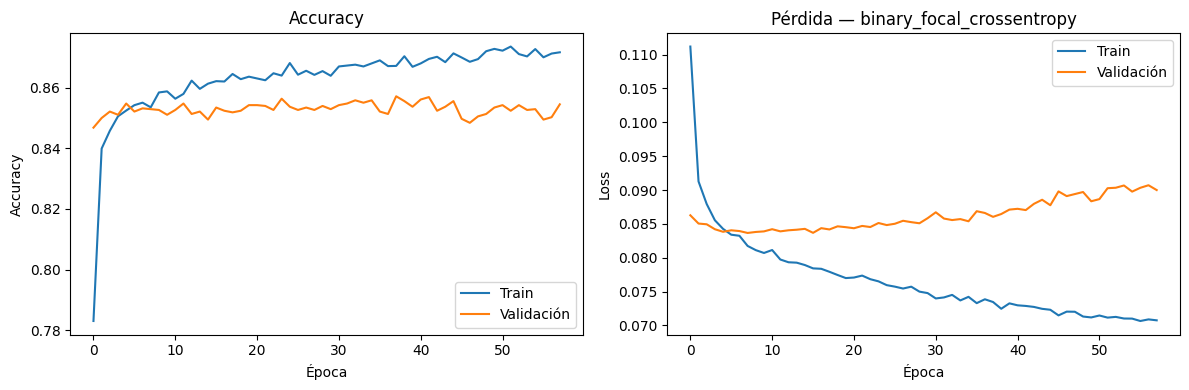

(None, None)

In [9]:
from sklearn.metrics import f1_score, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt
import warnings
warnings.filterwarnings('ignore')

def build_model(hp):
    model = Sequential([
        Input(shape=(X_train_tl.shape[1],)),
        Dense(hp.Choice('units_1', [64, 128, 256]), activation='relu'),
        Dropout(hp.Float('dropout_1', 0.3, 0.5, step=0.1)),
        Dense(hp.Choice('units_2', [32, 64, 128]), activation='relu'),
        Dropout(hp.Float('dropout_2', 0.3, 0.5, step=0.1)),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(hp.Choice('lr', [1e-2, 1e-3, 5e-4])),
        loss='binary_focal_crossentropy',
        metrics=['accuracy']
    )
    return model

tuner = kt.BayesianOptimization(
    build_model, objective='val_loss',
    max_trials=10, seed=42,
    project_name='mlp_salario', overwrite=True
)

tuner.search(
    X_train_tl, Y_train_tl,
    validation_data=(X_val.values, Y_val.values),
    epochs=50, batch_size=64,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=0
)

best_hp = tuner.get_best_hyperparameters()[0]
print(f'Mejores hiperparámetros:')
print(f'  units_1:  {best_hp.get("units_1")}')
print(f'  dropout_1:{best_hp.get("dropout_1")}')
print(f'  units_2:  {best_hp.get("units_2")}')
print(f'  dropout_2:{best_hp.get("dropout_2")}')
print(f'  lr:       {best_hp.get("lr")}')

# Entrenamiento final
tf.random.set_seed(42)
best_model = build_model(best_hp)

history = best_model.fit(
    X_train_tl, Y_train_tl,
    validation_data=(X_val.values, Y_val.values),
    epochs=100, batch_size=64,
    callbacks=[EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)],
    verbose=1
)

pred_mlp = (best_model.predict(X_test.values, verbose=0).flatten() > 0.5).astype(int)
print(f'F1 weighted (θ=0.5): {f1_score(Y_test, pred_mlp, average="weighted"):.4f}')
print(classification_report(Y_test, pred_mlp, target_names=['<=50K', '>50K']))

# Curvas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validación')
axes[0].set_title('Accuracy'), axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy'), axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Validación')
axes[1].set_title('Pérdida — binary_focal_crossentropy')
axes[1].set_xlabel('Época'), axes[1].set_ylabel('Loss'), axes[1].legend()
plt.tight_layout(), plt.show()

## Comparativa final de modelos — Aprendizaje Supervisado

Se han evaluado todos los modelos requeridos sobre el mismo conjunto de test interno (15% del dataset, `random_state=42`), aplicando TomekLinks exclusivamente sobre `X_train` para el tratamiento del desbalanceo. La métrica principal es el **F1-score weighted average** con umbral fijo θ=0.5.

| Modelo | Hiperparámetros óptimos | F1 weighted | F1 >50K | Recall >50K | Precisión >50K |
|---|---|---|---|---|---|
| Reg. Lineal (OLS) | — | 0.8404 | 0.63 | 0.57 | 0.70 |
| Reg. Lineal Ridge | α=0.001 | 0.8404 | 0.63 | 0.57 | 0.70 |
| Reg. Lineal Lasso | α=0.0001 | 0.8376 | 0.62 | 0.56 | 0.69 |
| Reg. Polinomial grado 2 | Ridge α=1 | 0.8400 | 0.64 | 0.63 | 0.66 |
| Reg. Logística | C=10, l1_ratio=0.25 | 0.8372 | 0.64 | 0.62 | 0.66 |
| Árbol de Decisión | entropy, depth=None, split=100, leaf=20 | 0.8307 | 0.63 | 0.62 | 0.64 |
| **Random Forest** ⭐ | 200 árboles, sqrt, depth=20, leaf=1 | 0.8353 | 0.63 | 0.59 | 0.67 |
| Extra Trees | 200 árboles, sqrt, depth=20, leaf=1 | 0.8364 | 0.63 | 0.60 | 0.67 |
| KNN | k=11, distance, Euclídea | 0.8182 | 0.61 | 0.62 | 0.59 |
| SVM Lineal | C=100 | 0.8381 | 0.63 | 0.60 | 0.67 |
| **SVM RBF** ⭐ | C=10, γ=scale | **0.8446** | **0.66** | **0.64** | **0.67** |
| **SVM Polinomial** ⭐ | C=1, d=2, γ=scale | 0.8437 | 0.64 | 0.60 | 0.69 |
| SVM Sigmoid | C=100, γ=0.001 | 0.8373 | 0.63 | 0.60 | 0.67 |
| **MLP Keras** ⭐ | units=64-32, dropout=0.4/0.3, lr=0.001 | 0.8375 | 0.64 | 0.63 | 0.65 |

---

### Observaciones

Los cuatro candidatos al mejor modelo (⭐) presentan perfiles complementarios:

- **SVM RBF** lidera en F1 weighted y en F1 de la clase minoritaria, siendo el único modelo que supera 0.65 en F1 `>50K`.
- **SVM Polinomial** queda a 0.0009 del RBF con mayor precisión en `>50K` (0.69 vs 0.67), cometiendo menos falsos positivos.
- **MLP Keras** iguala al polinomial en F1 `>50K` (0.64) con el mejor recall de la clase minoritaria entre los cuatro candidatos (0.63), a costa de algo de precisión.
- **Random Forest** es el único ensemble que compite con los anteriores, aunque muestra el overfitting más pronunciado (F1 train 0.9294 vs test 0.8353).

Dado que las diferencias entre candidatos no son sustanciales en el conjunto de test interno, **la evaluación en Kaggle sobre datos completamente nuevos será el criterio definitivo** para determinar cuál generaliza mejor fuera del dominio de entrenamiento.